# GHSL — building height

Download GHS-BUILT-H (average net building height, ANBH) for 2018 at 100 m over the Lisbon AOI.

In [1]:
import tempfile
from earthlens import EarthLens
out = tempfile.mkdtemp()
paths = EarthLens(
    data_source='ghsl', variables=['built_height'],
    start='2018-01-01', end='2018-12-31',
    lat_lim=[38.68, 38.78], lon_lim=[-9.20, -9.10], path=out,
).download(progress_bar=False)
paths

2026-05-28 22:48:37 | INFO | pyramids.base.config | Logging is configured.


[WindowsPath('C:/Users/main/AppData/Local/Temp/claude/tmp1icma0xx/GHS_BUILT_H_ANBH_E2018_100m_epsg4326.tif')]

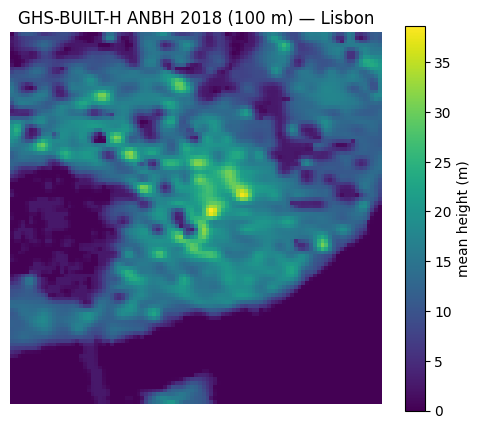

In [2]:
import numpy as np, matplotlib.pyplot as plt
from pyramids.dataset import Dataset
arr = np.asarray(Dataset.read_file(str(paths[0])).read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
arr = np.where(arr < 0, np.nan, arr)
plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='viridis'); plt.colorbar(label='mean height (m)')
plt.title('GHS-BUILT-H ANBH 2018 (100 m) — Lisbon'); plt.axis('off'); plt.show()